In [1]:
import sys
import os

current_path = os.getcwd()
parent_path = os.path.dirname(current_path)
sys.path.append(parent_path)

import scipy as sp
import funcTidal
import funcRotor
import funcConstraint
import funcSimRotor
import funcLCOE
import funcMain
import constUnitConvert
import constGlobal
import constVessel

CONVERT = constUnitConvert.ConstantsUnitConversion()
GLOBAL = constGlobal.ConstantsGlobal()


import urllib3 # Disable the InsecureRequestWarning 
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


This tutorial provide an example of performing brute force optimization.

First define the Simulation Condition
- the tidal data from NOAA buoy station `myStation`
- cut-in speed `Umin`
- if brake is used or not `withBrake`
- the Vessel properties `VESSEL`
- if we want to scale the rated power **this is only useful for constraint minimization, leave this as None**   `scalePrated = None`

Then define the grid points for the brute force optimization. The variables are radiusm rated power, hub depth and number of turbine. It must be in the order minimum, maximum and timestep. 

In [2]:
myStation = "SEA0711"
Umin = None
withBrake = True
VESSEL = constVessel.FISH
scalePrated = None

# Define Brute Range
RrMin, RrMax, RrStep = 3.0, 3.4, 0.2
PratedMin, PratedMax, PratedStep = 2.0e3, 4.0e3, 1.0e3
dHubMin, dHubMax, dHubStep = 3.0, 5.0, 1.0
nTurbineMin, nTurbineMax, nTurbineStep = 3.0, 5.0, 1.0


Load Tidal and Rotor data

In [3]:
station = myStation
startdate = 20210901
rangeHr = 2 * 7 * 24
timestep = 0.2

Uinf, t, dMoor, buoyLatitude, buoyLongitude = funcTidal.loadTidal(station, startdate, rangeHr, timestep)
print(f"Mooring depth is {dMoor} [m].")

AlaskaCityLocationData = "../../TurboShipCostCalculator/AlaskaCityLatLong.txt"

dCable, CityName = funcTidal.calCableLen(buoyLatitude, buoyLongitude,AlaskaCityLocationData)
cable_length_miles = dCable * CONVERT.m2mile
print(f"Cable length is {round(cable_length_miles, 2)} miles and the closest city is {CityName}.")

AeroDynFolderPath = "../../TurboShipCostCalculator/Original_MHKF1_ARLScaled_20Sections_5ms_VariedPitch_Cp/"
myTSRmax = 10.0
myTSRmin = 0.0

CpFunc, CtFunc, CpminFunc, spanRatio, CpOpt, TSROpt = funcRotor.loadRotorSurfaces(AeroDynFolderPath, myTSRmax, myTSRmin)
bladeVolume, baseMass, baseRadius, bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath)


Mooring depth is 35.4 [m].
Cable length is 2.2 miles and the closest city is Ketchikan.


Print Simulation Condition

In [4]:
funcMain.printSimulationDetails(Umin, withBrake, scalePrated, VESSEL, station, startdate, rangeHr, timestep, Uinf, dMoor, cable_length_miles, CityName)


Simulation Conditions:
Minimum Flow Speed (Umin): None
Brake Enabled: Yes
Scale of Prated: None W
Vessel Type: Fish

Tidal Simulation Details:
Station: SEA0711
Start Date: September 01, 2021
Simulation Range: 336 hours
Timestep: 0.2 seconds
Minimum Flow from Uinf: 0.00 m/s
Maximum Flow from Uinf: 0.80 m/s
Mean Flow from Uinf: 0.37 m/s
Mooring Depth: 35.4 meters
Cable Length: 2.20 miles
Closest City: Ketchikan


Brute Optimization

<font color='red'>This section of code takes a while to run. It is simulating the rotor dynamic and running it for call cases specified. **Could take more than 15 mins** </font>

In [5]:
rranges = (
    slice(RrMin, RrMax+RrStep, RrStep),
    slice(PratedMin, PratedMax+PratedStep, PratedStep),
    slice(dHubMin, dHubMax+dHubStep, dHubStep),
    slice(nTurbineMin, nTurbineMax+nTurbineStep, nTurbineStep)
)

total_cases = funcMain.calculateTotalCases(rranges)
print(f"Total number of cases: {total_cases}")

xopt, fval, grid, Jout = sp.optimize.brute(
    funcMain.objectiveFuncBrute,
    ranges=rranges,
    args=(dMoor, Uinf, t, CpFunc, CtFunc, CpminFunc, spanRatio, CpOpt, TSROpt, baseRadius, baseMass, Umin, VESSEL, dCable, withBrake),
    full_output=True,
    finish=None,
    disp=True,
    workers=-1
)


Total number of cases: 256


Process brute force result

Optimal LCOE is [$/kWh]: 1.0204 
 - Radius [m]:  3.20 
 - Turbine Power Rating [W]: 3000.00 
 - Hub depth [m]:  4.00 
 - Number of turbine:  4.00


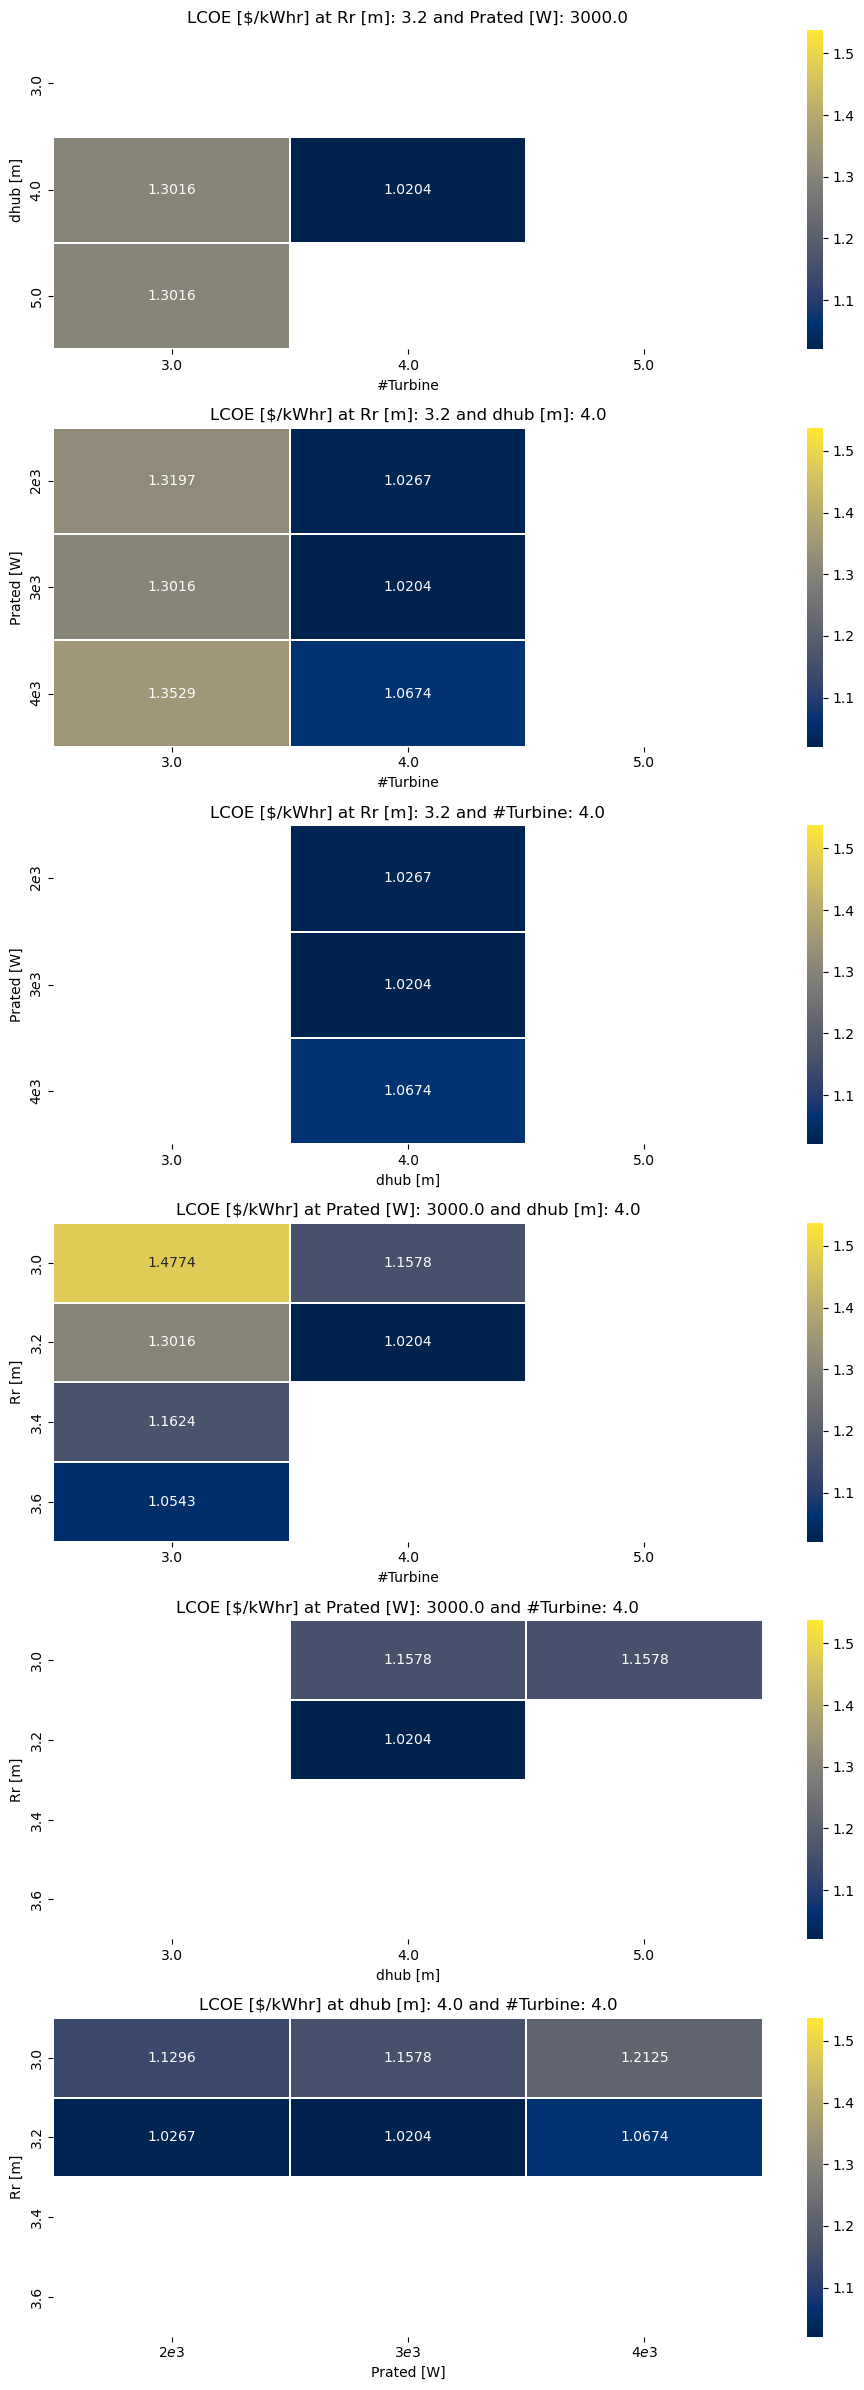

In [6]:
funcMain.processBruteOutput(xopt, fval, grid, Jout, station, startdate, VESSEL, Umin, withBrake)

Plot Result at Optimal Point

In [7]:

Radius, Prated, dHub, NumTurbine = xopt

w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th = funcSimRotor.simRotor(Radius, Prated, dHub, dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, Umin, withBrake)

Uinf_update = funcTidal.flowAtDepth(Uinf, Radius, dHub, dMoor)
F_vessel_thrust = funcConstraint.calForceMoorThrustFunc(Uinf_update, VESSEL)
F_turbine_thrust = funcSimRotor.calForceThrustFunc(Radius, Uinf_update, CtFunc(TSR))

LCOE, CostBreakdown = funcLCOE.calculate_cost(Radius, Prated, NumTurbine, dCable, dMoor, F_vessel_thrust, F_turbine_thrust, Pelec, t)


Running rotor simulation for Radius = 3.2, Prated = 3000.0, dHub = 4.0.


Print the cost brake down using build in bunction, the statistic of the rotor dynamic simulation results and the time domain dynamic plots. 

Cost Breakdown:
LCOE: $1.02
CAPEX: $151201.77
Et: $23331.95
cable: $27582.67
grid connect: $341.83
moor: $6142.81
blade: $1282.93
generator: $5350.87
misc: $564.02
hub: $2529.56
cable install: $100206.99
Rotor Dynamics (Mean) [SI units are assumed]:
w: 0.50
Tc: 986.71
TSR: 4.31
Pmech: 739.85
Pelec: 665.87
Phydro: 740.69
Pfluid: 1706.72
Punc: 747.86
Ft: 2518.47
Th: 987.49
Rotor Dynamics (Max) [SI units are assumed]:
w: 1.08
Tc: 3201.17
TSR: 20.82
Pmech: 3333.33
Pelec: 3000.00
Phydro: 3722.71
Pfluid: 8580.42
Punc: 3759.83
Ft: 8796.28
Th: 3434.47


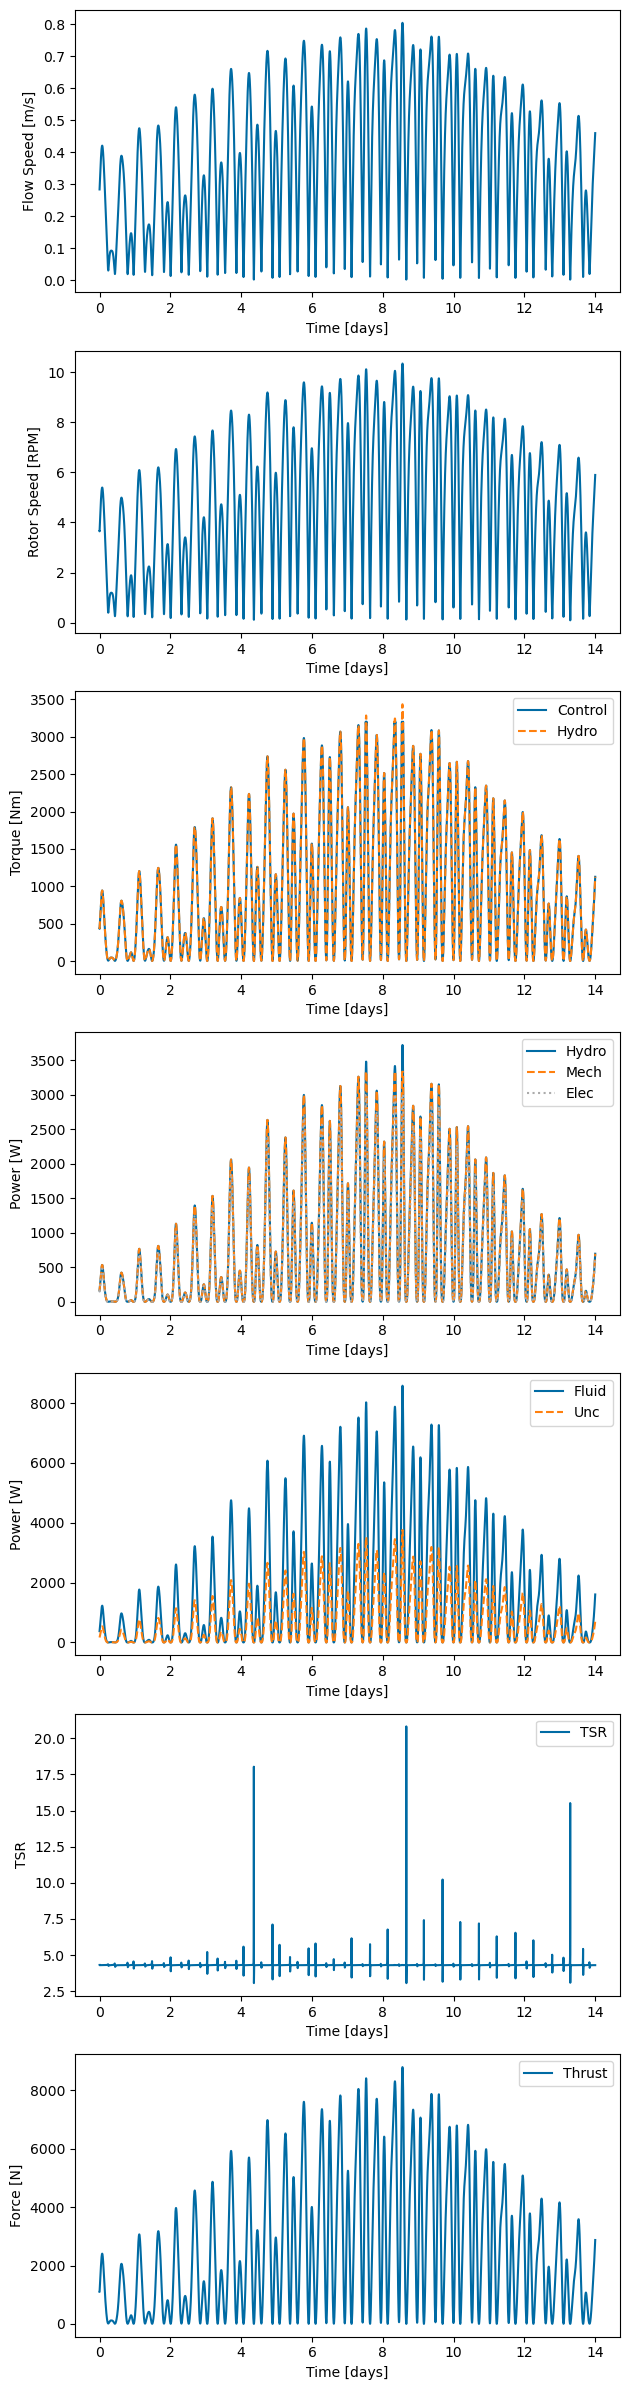

In [8]:

funcLCOE.printCostBreakdown(CostBreakdown)
funcSimRotor.printSimRotorStatistic(w,Tc,Pmech,Pelec,Phydro,Pfluid,Punc,TSR,Ft,Th)
funcSimRotor.plotTimeDomainResult(Uinf, t, w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th, station, startdate, VESSEL, Umin, withBrake)


Use build in function to vidualise vessel pitch constraint

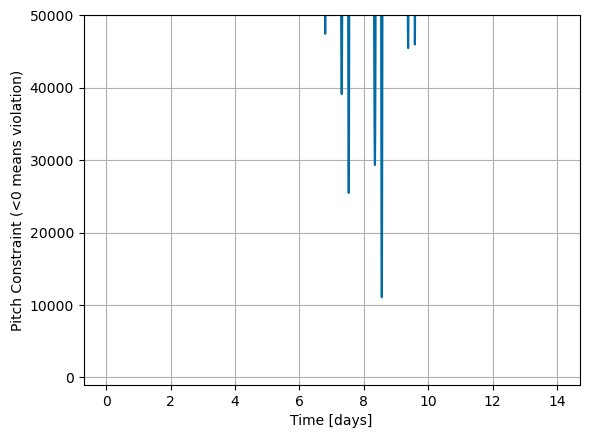

In [9]:

ylim = [-1000, 50000] # for plotting graph
funcConstraint.plotPitchCon(Radius, dHub, dMoor, Uinf, CtFunc, TSR, VESSEL, NumTurbine, t, ylim)


Use build in function to vidualise cavitation constraint

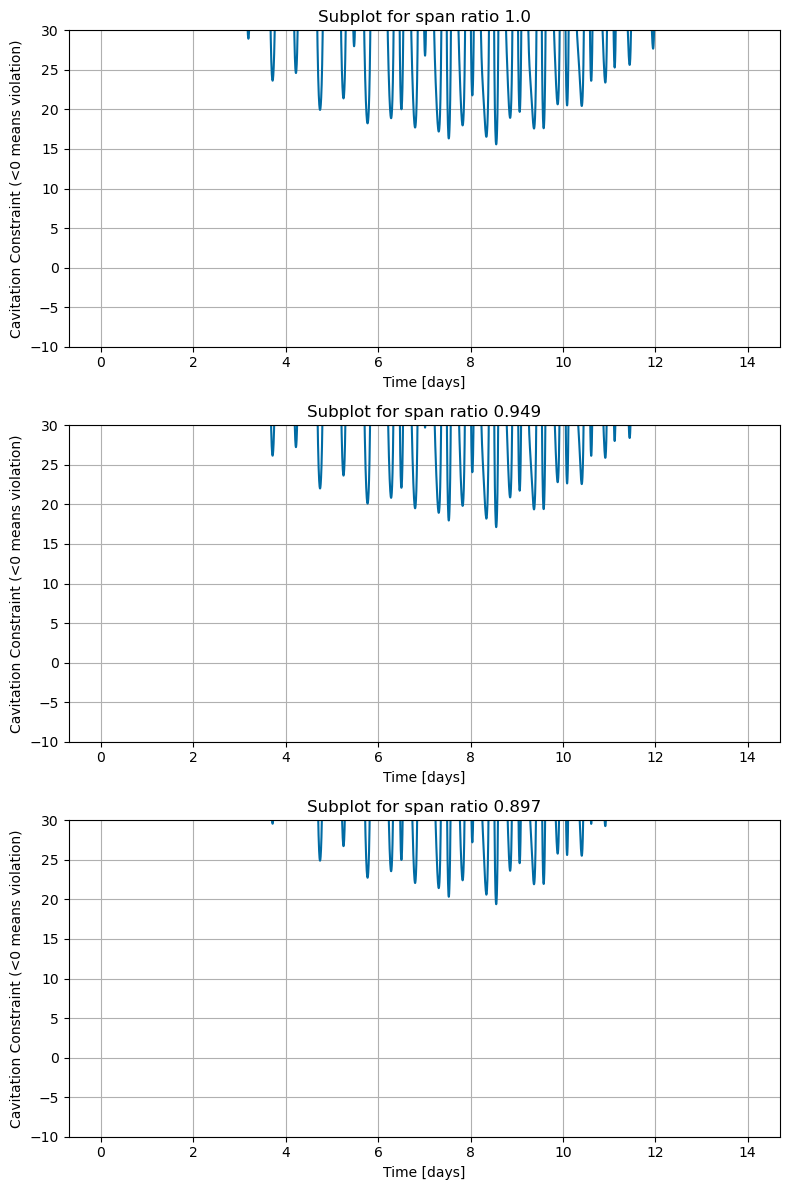

In [10]:
import importlib
importlib.reload(funcConstraint)
ylim = [-10, 30] # for plotting graph

funcConstraint.plotCavitationCon(Radius, dHub, dMoor, Uinf, w, TSR, CpminFunc, spanRatio, t, ylim)